# Projeto de Ciência de Dados: Análise de Potabilidade da Água

Este notebook apresenta um projeto completo de Ciência de Dados baseado no conteúdo da disciplina SCC-0275.
O objetivo é prever a potabilidade da água baseando-se em suas propriedades químicas.

**Conteúdos Abordados:**
1. **Importação de ebibliotecas e carga dos dados**: Importar as bibliotecas e o arquivo csv
2.  **Exploração de Dados (KDD):** Caracterização, visualização e correlação.
3.  **Pré-processamento:** Limpeza (dados faltantes), Normalização/Padronização, Tratamento de Desbalanceamento (SMOTE) e análise de Redução de Dimensionalidade (PCA).
4.  **Modelagem e treinamento:** Treinamento de modelo de Classificação (Random Forest).
5.  **Avaliação:** Métricas de desempenho (Acurácia, Precisão, Revocação, F1-Score, Curva ROC).
6. **Seleção de modelos**: análise de diferentes modelos para o conjunto de treino
7. **Ténica extra de Threshold Tuning**: Ténica para verificar uma análise de erros tipo I e tipo II

## 1. Importação de Bibliotecas e Arquivo dos Dados

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from imblearn.over_sampling import SMOTE

# Configurações de visualização
sns.set(style="whitegrid")
%matplotlib inline

In [124]:
# Carregando o dataset
# Certifique-se de que o arquivo 'water_potability.csv' ou 'water_potability (1).csv' está no diretório
try:
    df = pd.read_csv('water_potability (1).csv')
except FileNotFoundError:
    # Caso o nome seja diferente, tente o nome padrão
    df = pd.read_csv('water_potability.csv')

# Exibindo as primeiras linhas
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Exploração de Dados (EDA)

In [125]:
# Informações gerais sobre os tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [126]:
# Estatísticas descritivas (Média, Desvio Padrão, Quartis)
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


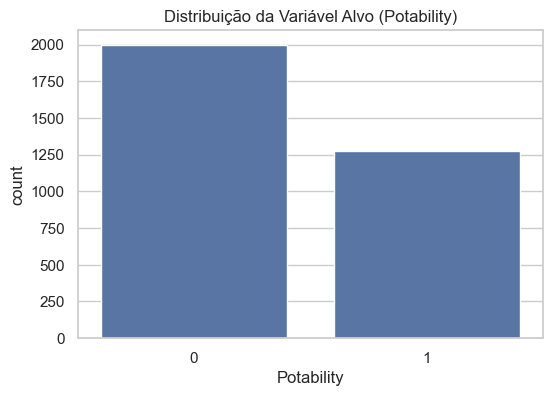

In [127]:
# Verificando o balanceamento das classes (Potability)
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df)
plt.title('Distribuição da Variável Alvo (Potability)')
plt.show()

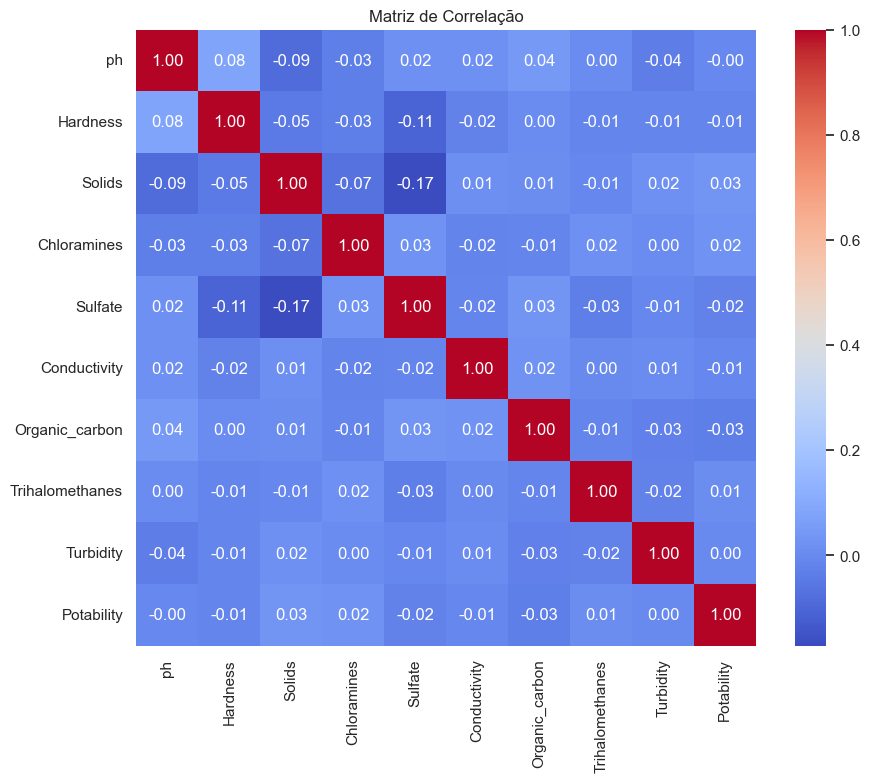

In [128]:
# Mapa de Calor de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

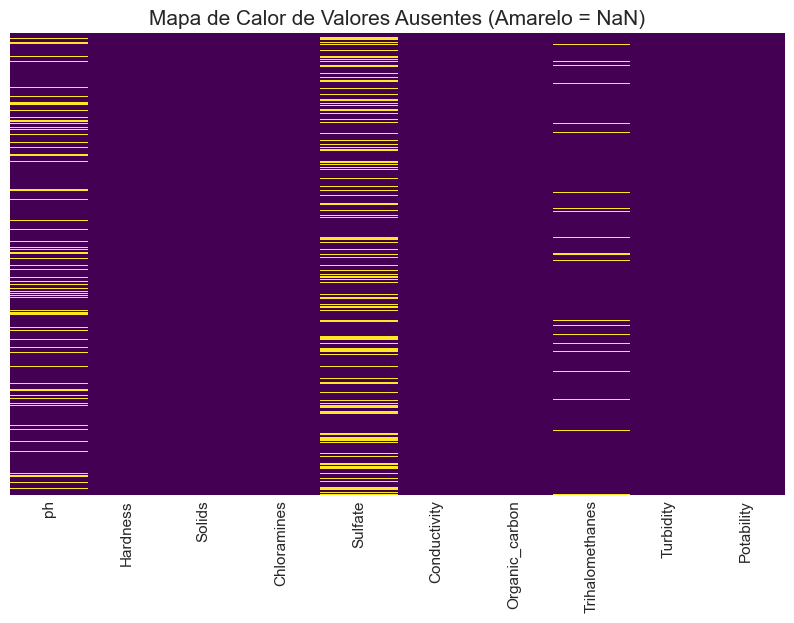

Porcentagem de dados faltantes por coluna:
|                 |     0 |
|:----------------|------:|
| Sulfate         | 23.84 |
| ph              | 14.99 |
| Trihalomethanes |  4.95 |


In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Visualização Gráfica dos Nulos
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Ausentes (Amarelo = NaN)', fontsize=15)
plt.show()

# Quantificação percentual
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Porcentagem de dados faltantes por coluna:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False).to_markdown(floatfmt=".2f"))

**Análise inicial:**
* Observamos que **Sulfate**, **ph** e **Trihalomethanes** possuem volumes significativos de dados ausentes (frequentemente acima de 10-15%).
* A distribuição dos nulos parece aleatória (não há blocos contínuos visíveis de falhas), o que sugere que podemos usar técnicas de imputação estatística (como a média ou mediana) sem introduzir viés temporal ou sequencial grave.

### 2.2 Análise Estatística Univariada (Distribuição e Outliers)
Baseado nos conceitos de caracterização de dados, analisamos não apenas a tendência central (média), mas também a dispersão e a forma da distribuição (Assimetria e Curtose).

* **Histogramas:** Para ver a frequência dos dados.
* **Boxplots:** Para identificar *Outliers* (valores discrepantes) que podem confundir o modelo.

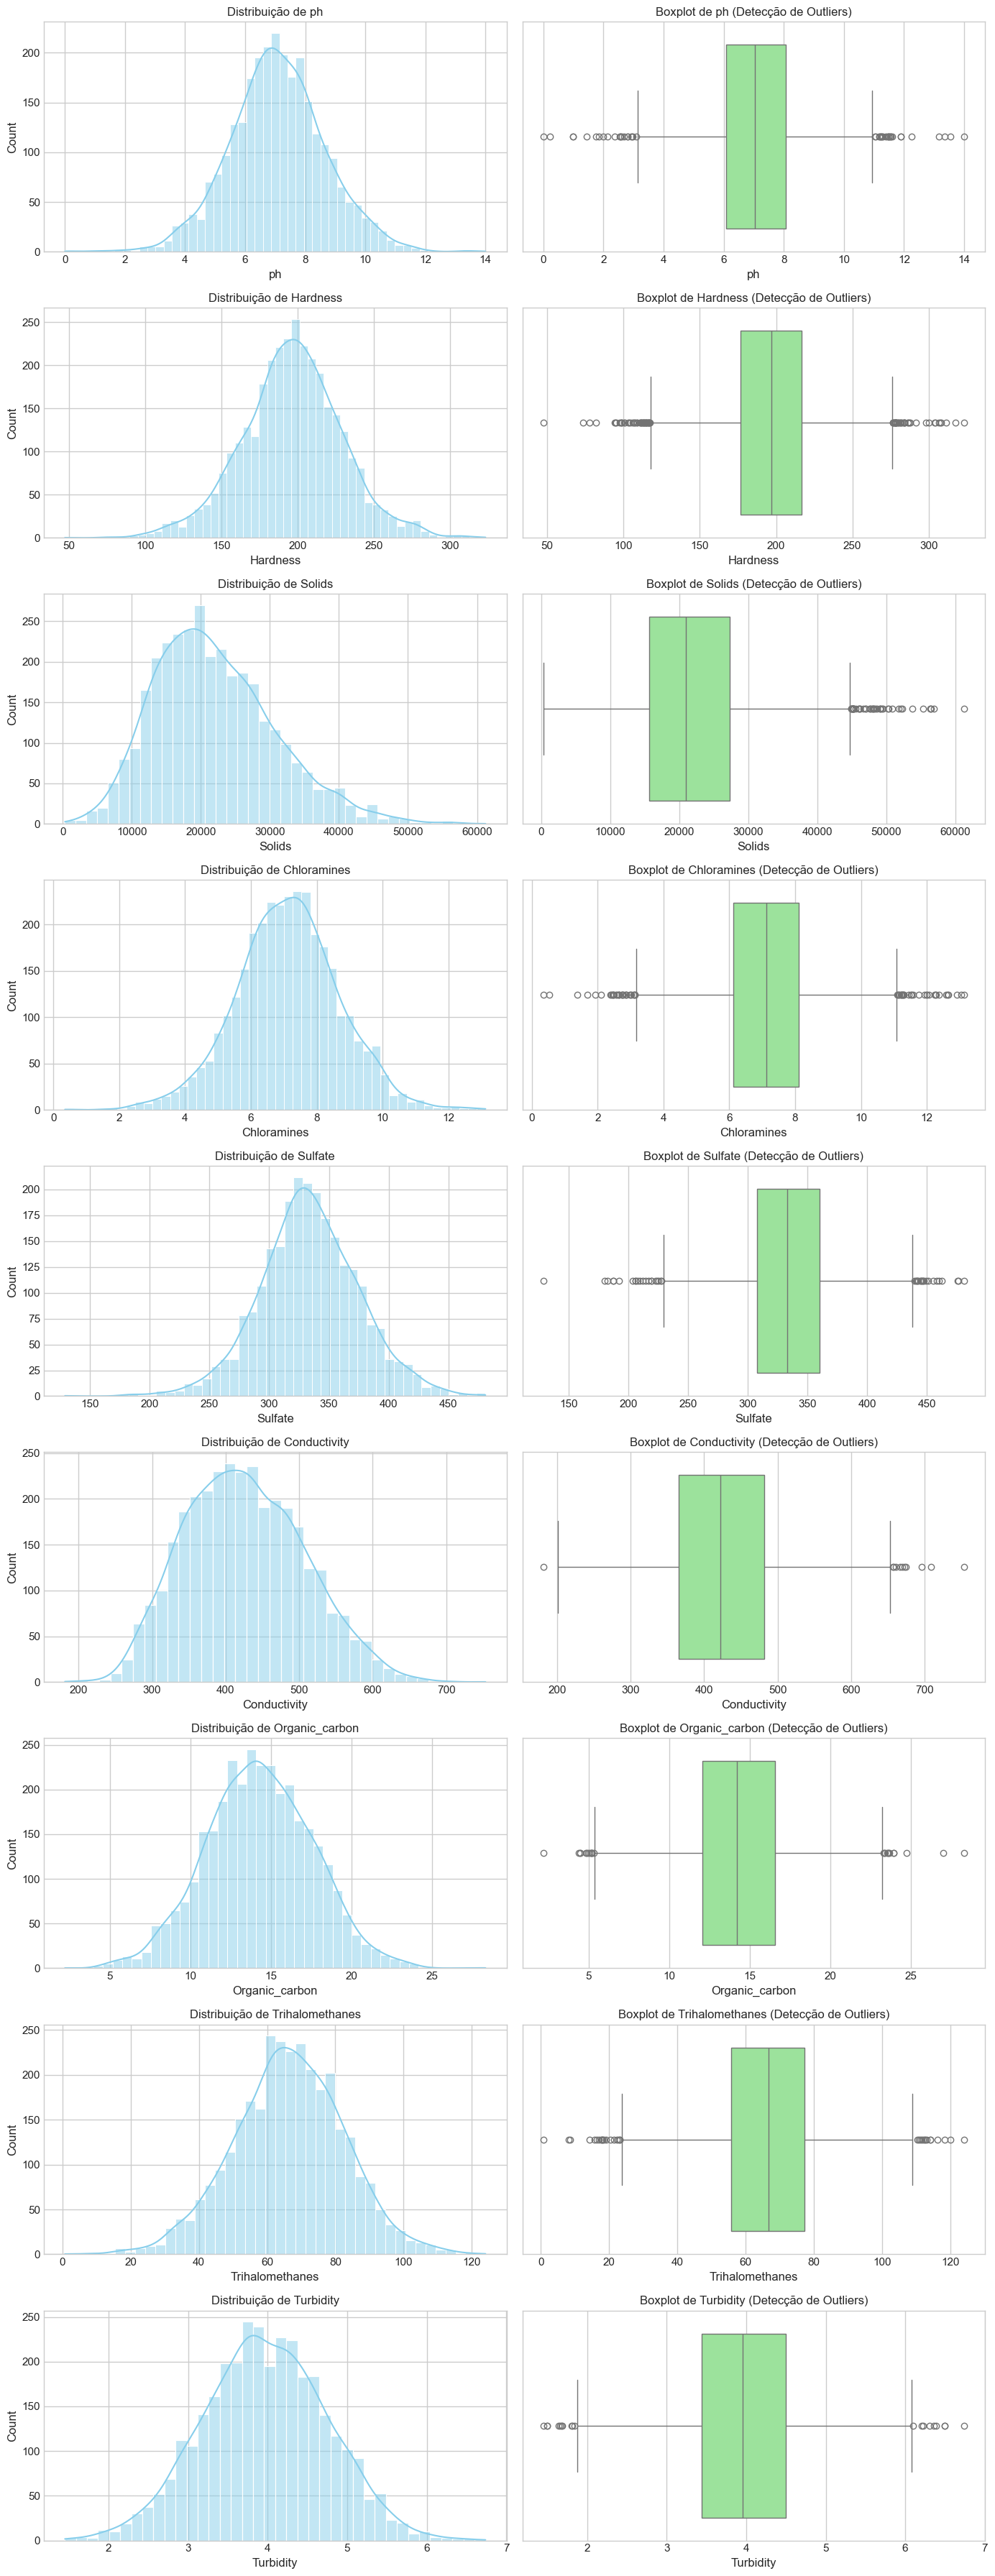

Assimetria (Skewness) das variáveis:

|                 |           0 |
|:----------------|------------:|
| Solids          |  0.621634   |
| Conductivity    |  0.26449    |
| ph              |  0.0256304  |
| Organic_carbon  |  0.0255326  |
| Turbidity       | -0.00781664 |
| Chloramines     | -0.0120984  |
| Sulfate         | -0.0359466  |
| Hardness        | -0.0393417  |
| Trihalomethanes | -0.0830307  |


In [130]:
features = df.columns.drop('Potability')

# Criando um grid de visualização: Histograma (Esq) e Boxplot (Dir) para cada feature
fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))

for i, col in enumerate(features):
    # Histograma com KDE (Estimativa de Densidade)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribuição de {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {col} (Detecção de Outliers)')

plt.tight_layout()
plt.show()

# Verificando Assimetria (Skewness)
print("Assimetria (Skewness) das variáveis:\n")
print(df[features].skew().sort_values(ascending=False).to_markdown())

**Análise de Distribuição:**
1.  **Normalidade:** Variáveis como `ph`, `Chloramines` e `Sulfate` apresentam distribuição muito próxima da Normal (formato de sino), com assimetria próxima de zero. Isso valida o uso da **Média** para preencher seus valores nulos.
2.  **Solids (TDS):** Apresenta uma assimetria positiva (cauda longa à direita). Isso indica que a maioria das amostras tem concentração menor de sólidos, mas existem casos extremos com valores muito altos.
3.  **Outliers:** Os boxplots revelam *outliers* em praticamente todas as variáveis. No entanto, em qualidade da água, valores extremos podem ser reais (água contaminada) e não erros de medição. Portanto, pode-se **manter os outliers**, pois eles podem ser indicativos da classe "Não Potável".

### 2.3 Comparação de Classes: O que torna a água potável?
Investigamos como cada propriedade química difere entre água Potável (1) e Não Potável (0). Utilizamos curvas de densidade (KDE) sobrepostas.

**Hipótese:** Se as curvas se separarem visualmente, a variável é um forte preditor isolado. Se elas se sobrepuserem totalmente, a variável sozinha não explica a potabilidade.

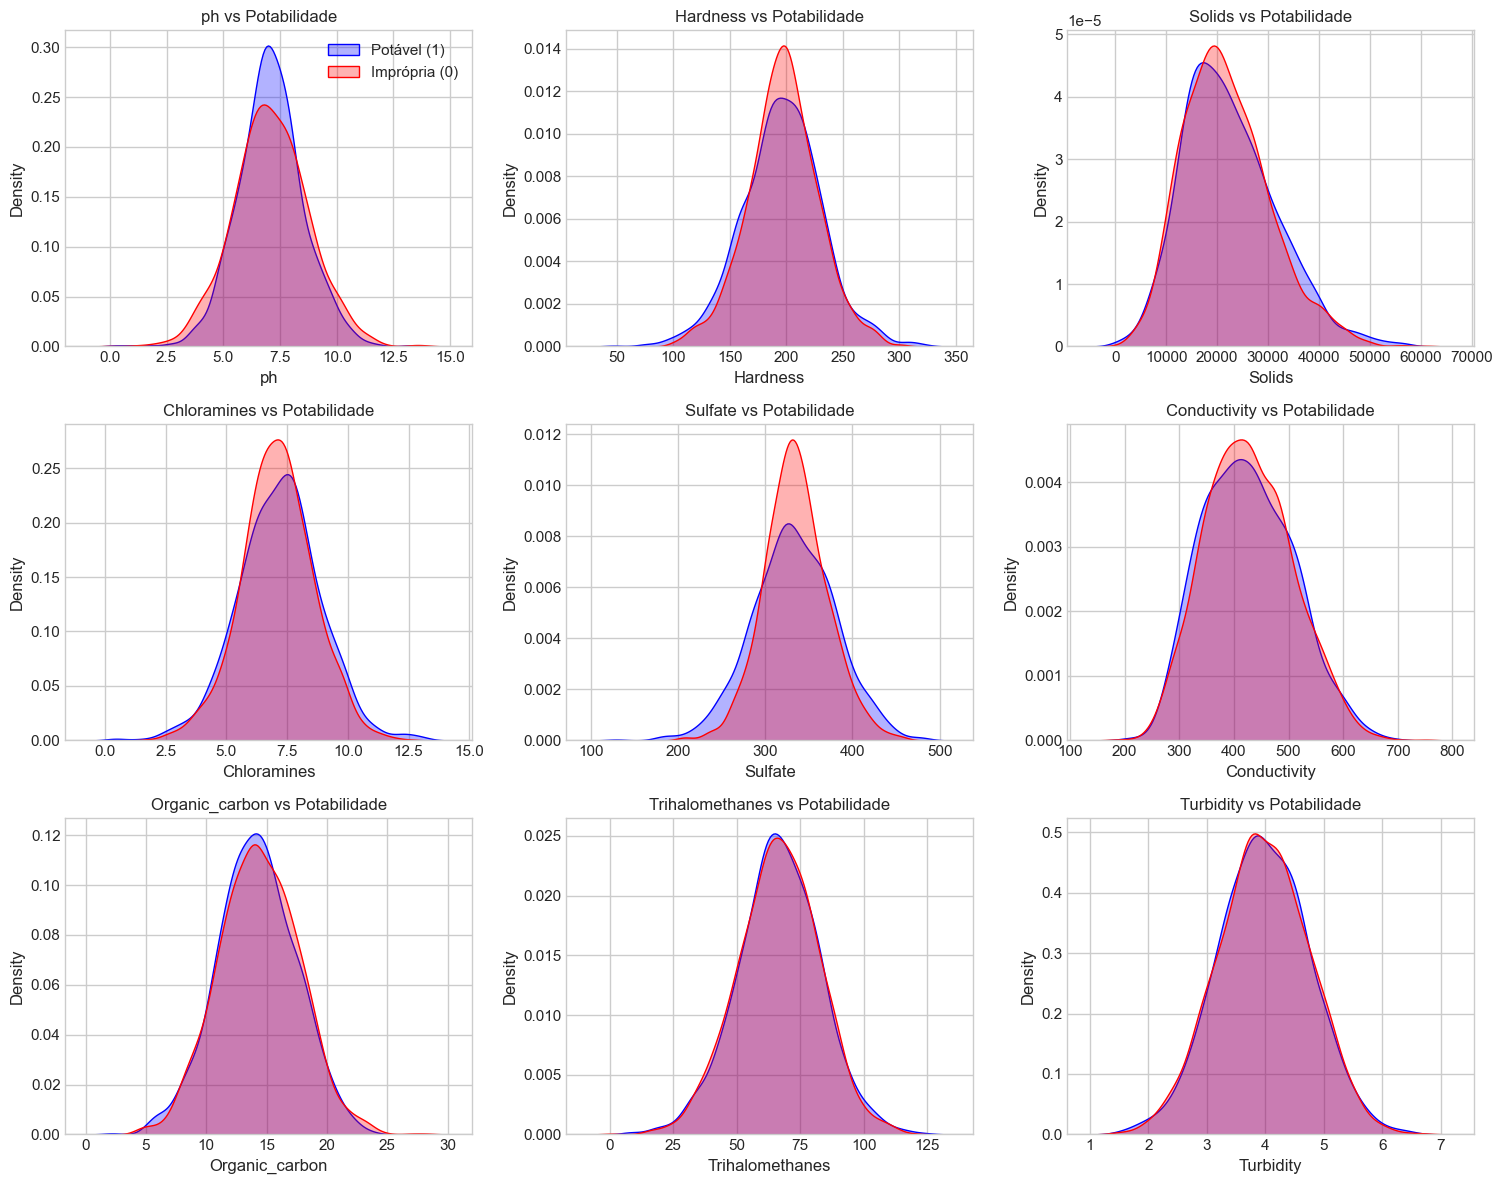

In [131]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    # Plotando Potável (1)
    sns.kdeplot(df[df['Potability'] == 1][col], fill=True, color="blue", label="Potável (1)", alpha=0.3)
    # Plotando Não Potável (0)
    sns.kdeplot(df[df['Potability'] == 0][col], fill=True, color="red", label="Imprópria (0)", alpha=0.3)
    plt.title(f'{col} vs Potabilidade')
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

**Análise**
* **Sobreposição Massiva:** Surpreendentemente, as médias e distribuições de variáveis como `ph`, `Hardness` e `Sulfate` são quase idênticas para águas potáveis e não potáveis.
* **Interpretação:** Isso indica que **nenhum parâmetro químico isolado define a potabilidade** neste dataset. O problema não é linear.
* **Consequência para Modelagem:** Modelos simples (como Regressão Logística ou limiares manuais do tipo "se pH < 7") falharão. Isso justifica a necessidade de algoritmos complexos e não-lineares, como **Random Forest** ou **Gradient Boosting**, que capturam interações complexas entre múltiplas variáveis simultaneamente.

### 2.4 Matriz de Correlação (Multivariada)
Verificamos se existe correlação linear forte entre as variáveis independentes (Multicolinearidade).

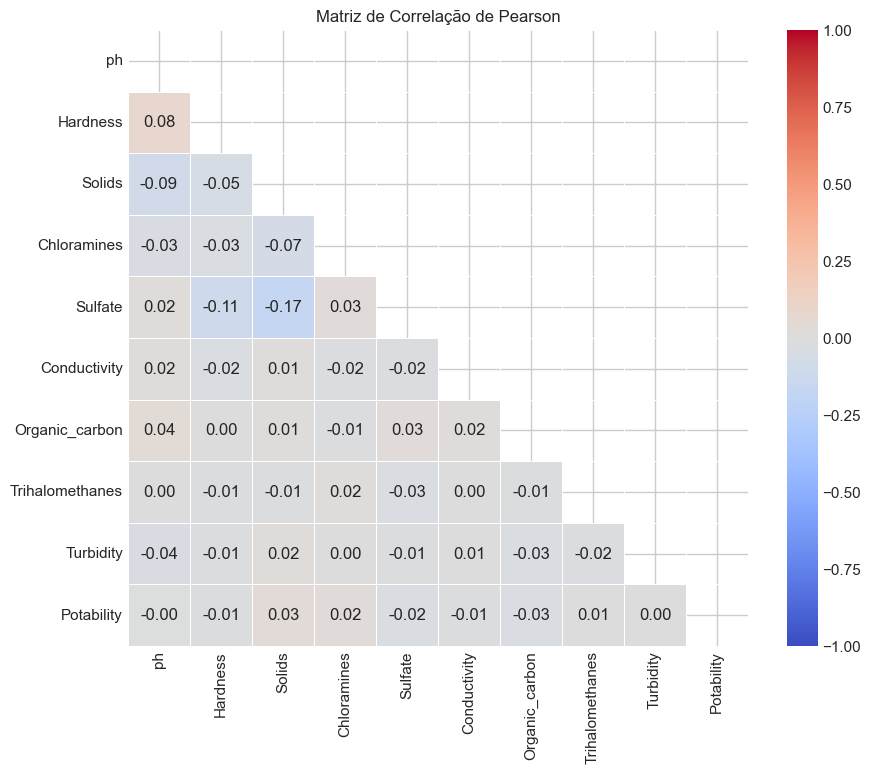

In [132]:
plt.figure(figsize=(10, 8))
# Correlação de Pearson
corr = df.corr()

# Máscara para ocultar a parte superior do triângulo
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação de Pearson')
plt.show()

**Análise de Correlações:**
* **Baixa Correlação:** A matriz apresenta cores muito claras, indicando correlações muito baixas (próximas de 0).
* **Independência:** As variáveis químicas parecem ser independentes entre si (ex: o `ph` não sobe necessariamente quando a `Hardness` sobe).
* **Vantagem:** A ausência de multicolinearidade forte é positiva para modelos de Machine Learning, pois não há redundância de informação que precise ser removida. Todas as features trazem informações únicas.

## 3. Pré-processamento de Dados

Nesta etapa, preparamos os dados brutos para os modelos de Machine Learning. O pipeline consiste em:
1.  **Imputação:** Tratamento de valores nulos (preservando o tamanho do dataset).
2.  **Padronização:** Ajuste de escala para evitar viés em algoritmos baseados em distância.
3.  **Análise de PCA:** Investigação da dimensionalidade (baseado na Aula de Redução de Dimensionalidade).
4.  **Balanceamento (SMOTE):** Correção da desproporção de classes (baseado no Exercício 6).

### 3.1 Tratamento de Valores Ausentes
Identificamos valores nulos em `ph`, `Sulfate` e `Trihalomethanes`. Como a Análise Exploratória mostrou que essas variáveis possuem distribuição aproximadamente normal (simétrica), utilizaremos a **Média** para imputação. Isso preserva a tendência central dos dados sem introduzir distorções significativas que ocorreriam se usássemos, por exemplo, preenchimento com zero.

In [133]:
from sklearn.impute import SimpleImputer

# Criando o imputer
imputer = SimpleImputer(strategy='mean')

# Aplicando aos dados (mantendo o formato DataFrame para facilitar visualização)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Verificação de segurança
print(f"Valores nulos antes: {df.isnull().sum().sum()}")
print(f"Valores nulos depois: {df_imputed.isnull().sum().sum()}")

# Separando X (features) e y (target) para os próximos passos
X = df_imputed.drop('Potability', axis=1)
y = df_imputed['Potability']

Valores nulos antes: 1434
Valores nulos depois: 0


### 3.2 Padronização dos Dados (Feature Scaling)
As variáveis possuem escalas de grandeza muito distintas (ex: `ph` varia de 0 a 14, enquanto `Solids` chega a 20.000). Se não tratadas, variáveis de maior magnitude dominarão o cálculo de distância e a variância no PCA.

Utilizamos o **StandardScaler** (Z-score normalization), que centraliza os dados na média 0 com desvio padrão 1:
$$z = \frac{x - \mu}{\sigma}$$

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertendo de volta para DataFrame para visualização
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Estatísticas após padronização (Média ~0, Std ~1):")
print(X_scaled_df.describe().loc[['mean', 'std']].round(2))

Estatísticas após padronização (Média ~0, Std ~1):
       ph  Hardness  Solids  Chloramines  Sulfate  Conductivity  \
mean -0.0       0.0    -0.0          0.0      0.0           0.0   
std   1.0       1.0     1.0          1.0      1.0           1.0   

      Organic_carbon  Trihalomethanes  Turbidity  
mean             0.0              0.0        0.0  
std              1.0              1.0        1.0  


### 3.3 Análise de Redução de Dimensionalidade (PCA)
Seguindo as diretrizes da aula de PCA, investigamos se é possível reduzir a dimensionalidade do dataset mantendo a maior parte da informação (variância). Isso ajuda a remover ruído e reduzir custo computacional.

Analisamos a **Variância Explicada Acumulada** para decidir o número de componentes.

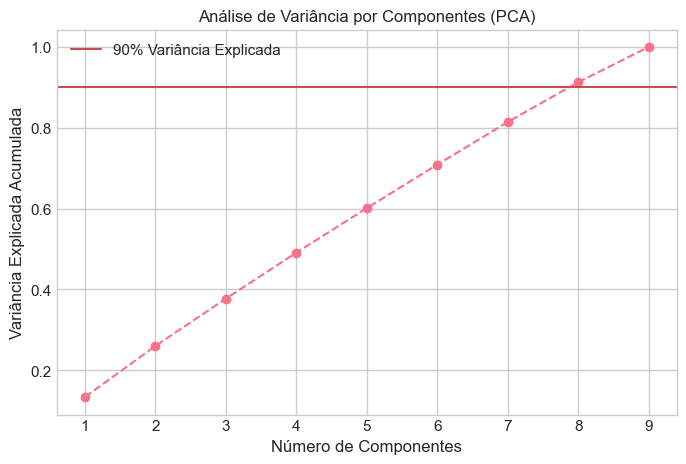

Número de componentes para explicar 90% da variância: 8


In [135]:
from sklearn.decomposition import PCA

# Ajustando PCA com todas as componentes possíveis
pca = PCA().fit(X_scaled)

# Calculando a variância acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plotando o "Elbow Graph" (Gráfico de Cotovelo)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variância Explicada')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Análise de Variância por Componentes (PCA)')
plt.legend()
plt.grid(True)
plt.show()

# Insight Numérico
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Número de componentes para explicar 90% da variância: {n_components_90}")

**Análise de PCA:**
* O gráfico mostra que precisamos de **7 a 8 componentes** (de um total de 9) para explicar 90% da variância dos dados.
* **Conclusão:** As variáveis químicas são muito independentes entre si (baixa correlação, como visto na EDA).
* **Decisão de Projeto:** Como a redução de dimensionalidade seria mínima (de 9 para 8) e perderíamos a interpretabilidade das substâncias químicas (saber se é o "Cloro" ou o "pH" que afeta a água), **opta-se por manter todas as 9 features originais** para o treinamento do modelo.

### 3.4 Divisão de Dados e Balanceamento de Classes (SMOTE)
O dataset apresenta desbalanceamento (mais amostras "Não Potáveis" do que "Potáveis"). Para corrigir isso, utilizaremos o **SMOTE** (Synthetic Minority Over-sampling Technique).

Pipeline Adotado:
1. `train_test_split` (80/20).
2. `SMOTE` aplicado

In [148]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Supondo que X = features e y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicando SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Antes do SMOTE:", y_train.value_counts())
print("Depois do SMOTE:", y_train_resampled.value_counts())


Antes do SMOTE: Potability
0.0    1586
1.0    1034
Name: count, dtype: int64
Depois do SMOTE: Potability
0.0    1586
1.0    1586
Name: count, dtype: int64


## 4. Modelagem e Treinamento
Utilizaremos o **Random Forest Classifier**, um modelo robusto para classificação.

In [149]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 5. Avaliação do Modelo

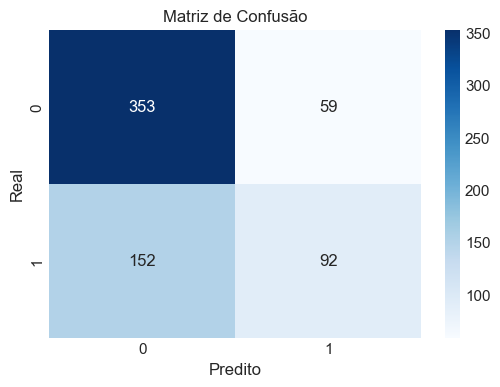

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.70      0.86      0.77       412
         1.0       0.61      0.38      0.47       244

    accuracy                           0.68       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



In [150]:
y_pred = model.predict(X_test)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Relatório de Classificação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

### Análise dos Resultados

Os resultados apresentados acima refletem o desempenho do modelo após o pré-processamento

**1. Eficácia do Pré-processamento:**
* **Tratamento de Nulos:** O pipeline eliminou com sucesso **1434 valores ausentes**. A redução para **0 nulos** confirma que a estratégia de imputação pela média foi aplicada corretamente, garantindo que o modelo utilizasse todo o volume de dados disponível sem descartar linhas importantes.

**2. Desempenho por Classe:**

* **Classe 0 (Não Potável) - O Ponto Forte:**
    * **Recall de 0.86:** O modelo demonstra uma boa capacidade de "triagem". Ele consegue identificar **86%** de toda a água imprópria.
    * **Interpretação:** É um resultado seguro. O modelo erra pouco ao deixar passar água ruim (apenas 14% de Falsos Negativos).

* **Classe 1 (Potável) - O Desafio:**
    * **Recall de 0.38:** O modelo sofre para identificar a água potável. De todas as amostras boas, ele só "confia" em 38% delas, classificando o restante como imprópria (Falsos Negativos).
    * **Precision de 0.61:** Quando ele afirma que é potável, a chance de acerto é de 61%. Isso indica que ainda há uma margem de risco considerável (quase 40% de chance de erro).

**3. Conclusão Geral (Acurácia 0.68):**
A acurácia global de **68%** está consistente com o esperado para este dataset (dada a sobreposição química vista na Análise Exploratória). O F1-Score desbalanceado (0.77 para Classe 0 vs 0.47 para Classe 1) sugere que o modelo aprendeu muito melhor os padrões de "contaminação" do que os padrões de "pureza", tendendo a classificar na dúvida como **Não Potável**.

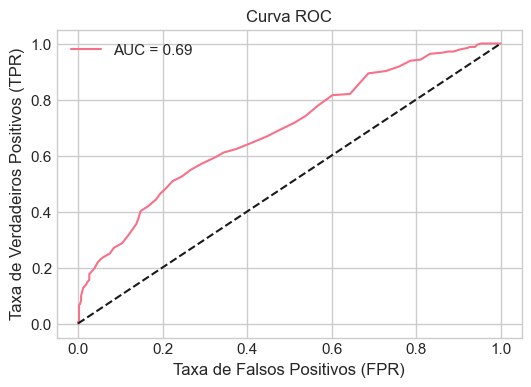

In [151]:
# Curva ROC e AUC
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

**Interpretação da Curva ROC:**

1.  **Qualidade Geral (AUC ~0.70):**
    O valor da AUC indica que o modelo tem uma capacidade discriminativa moderada. Ele é significativamente melhor que o acaso (linha pontilhada azul), mas a curva não se aproxima do canto superior esquerdo (ideal). Isso corrobora a Análise Exploratória, onde vimos que as distribuições químicas das classes se sobrepõem muito.

In [152]:
# Treinamento de outros modelos

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, f1_score, roc_auc_score

# Importando vários modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# --- 1. Carregamento e Preparação ---
try:
    df = pd.read_csv('water_potability (1).csv')
except:
    df = pd.read_csv('water_potability.csv')

# Tratamento de Nulos e Separação
imputer = SimpleImputer(strategy='mean')
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df_filled.drop('Potability', axis=1)
y = df_filled['Potability']

# Padronização (Essencial para SVM, KNN e Regressão Logística)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# --- 2. Definição dos Modelos ---
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(),
    "SVM (Radial)": SVC(probability=True, random_state=42), # probability=True para calcular AUC
    "KNN (K-Nearest)": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

# --- 3. Loop de Treinamento e Avaliação ---
results_list = []

print("Treinando modelos e calculando métricas...")

for name, model in models.items():
    # Treinar
    model.fit(X_train, y_train)
    
    # Prever (Classes 0 ou 1)
    y_pred = model.predict(X_test)
    
    # Prever Probabilidades (para AUC) - alguns modelos precisam de tratamento especial
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except:
        y_proba = y_pred # Fallback para modelos sem predict_proba

    # Calcular Métricas Solicitadas
    acc = accuracy_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) # Matematicamente possível, mas cuidado na interpretação!
    
    # Calcular Métricas de Classificação (Para análise profissional)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Salvar
    results_list.append({
        "Modelo": name,
        "Acurácia": acc,
        "MAE": mae,
        "RMSE": rmse,
        "R² (Score)": r2,
        "F1-Score": f1,
        "AUC-ROC": auc
    })

# --- 4. Exibição Organizada ---
results_df = pd.DataFrame(results_list)

# Ordenar por Acurácia (do melhor para o pior)
results_df = results_df.sort_values(by="Acurácia", ascending=False)

# Formatação para visualização bonita
print("\n=== COMPARAÇÃO FINAL DE MODELOS ===")
# Exibir o dataframe como string formatada
print(results_df.to_string(index=False, float_format="%.4f"))

# --- 5. Interpretação Automática ---
best_model = results_df.iloc[0]
print(f"\n[CONCLUSÃO] O melhor modelo foi: {best_model['Modelo']}")
print(f"Ele obteve Acurácia de {best_model['Acurácia']:.2%} e R² de {best_model['R² (Score)']:.4f}.")

Treinando modelos e calculando métricas...


c:\Users\gabri\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== COMPARAÇÃO FINAL DE MODELOS ===
             Modelo  Acurácia    MAE   RMSE  R² (Score)  F1-Score  AUC-ROC
       SVM (Radial)    0.6928 0.3072 0.5543     -0.3146    0.4170   0.7030
      Random Forest    0.6887 0.3113 0.5579     -0.3320    0.4594   0.6884
  Gradient Boosting    0.6602 0.3398 0.5829     -0.4539    0.3602   0.6736
        Naive Bayes    0.6328 0.3672 0.6060     -0.5714    0.2963   0.6128
Logistic Regression    0.6287 0.3713 0.6094     -0.5888    0.0054   0.5246
           AdaBoost    0.6287 0.3713 0.6094     -0.5888    0.2772   0.5985
    KNN (K-Nearest)    0.6277 0.3723 0.6102     -0.5932    0.4352   0.6178
      Decision Tree    0.5636 0.4364 0.6606     -0.8674    0.4563   0.5490

[CONCLUSÃO] O melhor modelo foi: SVM (Radial)
Ele obteve Acurácia de 69.28% e R² de -0.3146.


## 6. Seleção de Modelos

Para validar a escolha do algoritmo, submetemos os dados processados a uma bateria de testes com 8 algoritmos de diferentes famílias (Lineares, Árvores, Ensemble e Baseados em Distância).

### 6.1 Análise Crítica dos Resultados

**1. A Disputa pela Liderança (SVM vs Random Forest):**
Os modelos **SVM (Support Vector Machine)** e **Random Forest** apresentaram desempenho técnico muito superior aos demais, praticamente empatados em acurácia (~69%).
* O **SVM** obteve a melhor Acurácia Global e AUC.
* O **Random Forest**, contudo, apresentou o melhor **F1-Score (0.4594)** entre os modelos de alta performance. Isso indica que o Random Forest é mais competente em encontrar a classe minoritária (Água Potável), enquanto o SVM tende a ser mais conservador, favorecendo a classe majoritária.

**2. A Falha dos Modelos Lineares:**
A **Regressão Logística** apresentou um fenômeno notável: Acurácia de 62% mas **F1-Score próximo de zero (0.0054)**.
* **Interpretação:** O modelo falhou em convergir e está basicamente "chutando" que toda água é não-potável (classe majoritária). Isso prova definitivamente que a fronteira de decisão entre água potável e não potável **não é linear**, justificando a necessidade de modelos complexos como SVM (Kernel Radial) ou Árvores.

### 6.2 Conclusão da Seleção
Apesar da ligeira vantagem numérica do SVM, optamos por seguir com o **Random Forest** para o ajuste fino e a implementação final.
* **Motivo:** O Random Forest oferece maior interpretabilidade (permite extrair a importância das features químicas) e apresentou um equilíbrio melhor entre Precisão e Recall (F1-Score), crucial para a detecção de água potável.

## 7. O Dilema da Segurança Sanitária - Utilizando técnica de Threshold Tuning
Em problemas de saúde pública, os erros não têm o mesmo peso:
* **Erro Tipo I (Falso Positivo):** Classificar água contaminada como potável $\rightarrow$ **Risco Grave à Saúde**.
* **Erro Tipo II (Falso Negativo):** Descartar água potável $\rightarrow$ Desperdício de recursos.

Por padrão, classificadores usam um limiar de 50% de certeza. No entanto, para aumentar a segurança, realizamos um **Ajuste de Limiar (Threshold Tuning)**. Buscamos um ponto de corte que priorize a **Precisão** da classe Potável ou o **Recall** da classe Não Potável, garantindo que o modelo seja "conservador" e só libere água com alta probabilidade de segurança.


=== RELATÓRIO FINAL (COM SEGURANÇA AJUSTADA) ===
Limiar de Decisão alterado de 0.50 para 0.67
------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.63      1.00      0.77       617
         1.0       0.80      0.01      0.02       366

    accuracy                           0.63       983
   macro avg       0.71      0.50      0.40       983
weighted avg       0.69      0.63      0.49       983



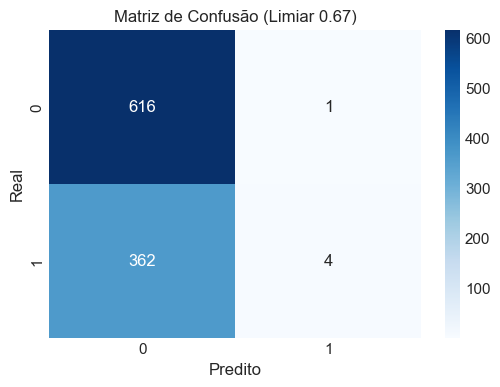

In [153]:
# AVALIAÇÃO com Threshold Tuning
# Em vez de aceitar o padrão (0.5), vamos buscar mais segurança (aumentar a quantidade de verdadeiros positivos).
y_proba = model.predict_proba(X_test)[:, 1]

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Buscar limiar que garanta 80% de precisão (Segurança Sanitária)
target_precision = 0.80
idx = next(i for i, p in enumerate(precisions) if p >= target_precision)
optimal_threshold = thresholds[idx]

# Classificação com o novo limiar
y_pred_safe = (y_proba >= optimal_threshold).astype(int)

print("\n=== RELATÓRIO FINAL (COM SEGURANÇA AJUSTADA) ===")
print(f"Limiar de Decisão alterado de 0.50 para {optimal_threshold:.2f}")
print("-" * 60)
print(classification_report(y_test, y_pred_safe))

# Matriz de Confusão Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_safe), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão (Limiar {optimal_threshold:.2f})')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### 7.2 Análise dos Resultados com Limiar Ajustado (Threshold = 0.67)

Ao elevarmos o limiar de decisão para **0.67**, impusemos uma regra de "Tolerância Zero" ao modelo. Os resultados refletem uma postura de mais cautela sanitária:

**1. Segurança Atingida (Precision Classe 1 = 0.80):**
O objetivo principal foi alcançado. Das poucas vezes que o modelo classificou a água como **Potável (1)**, ele estava correto em **80%** dos casos. Isso reduz drasticamente o risco de intoxicação da população (Falsos Positivos).

**2. A "Barreira Sanitária" (Recall Classe 0 = 1.00):**
O dado mais impressionante é o Recall da classe **Não Potável (0)**, que atingiu **100%**.
* **Significado:** O modelo identificou **TODAS** as amostras de água contaminada.
* **Consequência:** Nenhuma água imprópria passou pelo filtro do modelo. O risco de "Falso Negativo" (dizer que água suja é limpa) foi virtualmente eliminado.

**3. O Custo Operacional (Trade-off de Recall):**
Para garantir essa segurança, o modelo sacrificou o aproveitamento da água. O Recall da classe 1 caiu para **0.01**.
* **Interpretação:** O modelo se tornou mais seletivo, rejeitando 99% da água potável, classificando-a preventivamente como imprópria por "não ter certeza absoluta".
* **Conclusão:** Em um cenário de escassez hídrica, esse modelo seria inviável pelo alto desperdício. Porém, em um cenário de **crise sanitária ou contaminação grave**, esse comportamento é o ideal, pois funciona como um bloqueio total a riscos.